# Notebook Evaluasi Model Final ke Data Test

Mengevaluasi 5 model final ke data test masing-masing task.

**Output per task:**
- Classification Report (precision, recall, F1, support)
- Confusion Matrix
- ROC-AUC dan AUC-PR (per aspek untuk Task 1)
- Hamming Loss dan Subset Accuracy (Task 1)
- Perbandingan Train vs Test (deteksi overfitting)
- Prediksi disimpan ke CSV
- Rekap metrik disimpan ke Excel


## 1. Import dan Setup


In [ ]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import AUC
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    hamming_loss, accuracy_score,
    f1_score, precision_score, recall_score
)
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR  = '/content/drive/MyDrive/SKRIPSI_NAVY/'
FINAL_DIR = BASE_DIR + 'Dataset/Model_Final/'
SPLIT_DIR = BASE_DIR + 'Dataset/Dataset_SplitData/'
TOKEN_DIR = BASE_DIR + 'Dataset/Dataset_Tokenizer/'
MAX_LENGTH = 100

# ── Hasil K-Fold training untuk perbandingan ──
# Nilai ini diambil dari rekap skenario terbaik
# dan digunakan untuk mendeteksi overfitting
KFOLD = {
    # Task 1 ada 2 jenis accuracy:
    # hamming_acc = 1 - Hamming Loss (dicatat saat K-Fold)
    # subset_acc  = exact match (dihitung dari predictions_all_folds.csv)
    # Task 1 = Skenario 8 BILSTM FT STEM
    'Task1_Aspek'   : {'f1':0.9702,'precision':0.9671,
                       'recall':0.9734,
                       'accuracy':0.9762,      # hamming accuracy
                       'subset_acc': 0.9155},     # isi setelah run notebook subset acc
    # Task 2 = Skenario 4 CNN FT STEM
    'Task2_Room'    : {'f1':0.9784,'precision':0.9783,
                       'recall':0.9786,'accuracy':0.9785},
    # Task 3 = Skenario 5 BILSTM W2V NONSTEM
    'Task3_Hotel'   : {'f1':0.9656,'precision':0.9640,
                       'recall':0.9676,'accuracy':0.9672},
    # Task 4 = Skenario 1 CNN W2V NONSTEM
    'Task4_Location': {'f1':0.9737,'precision':0.9745,
                       'recall':0.9731,'accuracy':0.9815},
    # Task 5 = Skenario 2 CNN W2V STEM
    'Task5_Service' : {'f1':0.9796,'precision':0.9784,
                       'recall':0.9809,'accuracy':0.9812},
}

# ── Konfigurasi per task ──
TASKS = {
    'Task1_Aspek': {
        'model_path' : FINAL_DIR+'Task1_Aspek/model_final.h5',
        'test_file'  : SPLIT_DIR+'df_test_full.csv',
        'token_file' : TOKEN_DIR+'tokenizer_stem.pkl',
        'text_col'   : 'review_stemmed',
        'label_cols' : ['Room_label','Hotel_label',
                        'Location_label','Service_label'],
        'label_names': ['Room','Hotel','Location','Service'],
        'task_type'  : 'multilabel',
        'output_dir' : FINAL_DIR+'Task1_Aspek/',
    },
    'Task2_Room': {
        'model_path' : FINAL_DIR+'Task2_Room/model_final.h5',
        'test_file'  : SPLIT_DIR+'df_test_Task2_Room.csv',
        'token_file' : TOKEN_DIR+'tokenizer_stem.pkl',
        'text_col'   : 'review_stemmed',
        'label_cols' : ['Room_sentiment'],
        'label_names': ['Sentimen'],
        'task_type'  : 'binary',
        'minoritas'  : 'Positif', 'min_idx': 1,
        'output_dir' : FINAL_DIR+'Task2_Room/',
    },
    'Task3_Hotel': {
        'model_path' : FINAL_DIR+'Task3_Hotel/model_final.h5',
        'test_file'  : SPLIT_DIR+'df_test_Task3_Hotel.csv',
        'token_file' : TOKEN_DIR+'tokenizer_nonstem.pkl',
        'text_col'   : 'review_non_stemmed',
        'label_cols' : ['Hotel_sentiment'],
        'label_names': ['Sentimen'],
        'task_type'  : 'binary',
        'minoritas'  : 'Negatif', 'min_idx': 0,
        'output_dir' : FINAL_DIR+'Task3_Hotel/',
    },
    'Task4_Location': {
        'model_path' : FINAL_DIR+'Task4_Location/model_final.h5',
        'test_file'  : SPLIT_DIR+'df_test_Task4_Location.csv',
        'token_file' : TOKEN_DIR+'tokenizer_nonstem.pkl',
        'text_col'   : 'review_non_stemmed',
        'label_cols' : ['Location_sentiment'],
        'label_names': ['Sentimen'],
        'task_type'  : 'binary',
        'minoritas'  : 'Negatif', 'min_idx': 0,
        'output_dir' : FINAL_DIR+'Task4_Location/',
    },
    'Task5_Service': {
        'model_path' : FINAL_DIR+'Task5_Service/model_final.h5',
        'test_file'  : SPLIT_DIR+'df_test_Task5_Service.csv',
        'token_file' : TOKEN_DIR+'tokenizer_stem.pkl',
        'text_col'   : 'review_stemmed',
        'label_cols' : ['Service_sentiment'],
        'label_names': ['Sentimen'],
        'task_type'  : 'binary',
        'minoritas'  : 'Negatif', 'min_idx': 0,
        'output_dir' : FINAL_DIR+'Task5_Service/',
    },
}

pd.set_option('display.max_colwidth', None)
print('Setup selesai.')


Mounted at /content/drive
Setup selesai.


## 2. Fungsi Evaluasi


In [ ]:
def tampilkan_confusion_matrix(y_true, y_pred,
                                kelas, judul, path):
    """
    Menampilkan confusion matrix sebagai heatmap.
    Kotak merah = diagonal (prediksi benar).
    """
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=kelas, yticklabels=kelas, ax=ax)
    for i in range(len(kelas)):
        ax.add_patch(plt.Rectangle(
            (i, i), 1, 1, fill=False,
            edgecolor='red', lw=2))
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
    ax.set_title(judul, fontweight='bold')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()


def tampilkan_roc_pr(y_true, y_prob, nama_minoritas,
                     min_idx, judul, path):
    """
    ROC Curve: mengukur kemampuan model membedakan kelas.
    AUC-ROC mendekati 1 = model sangat baik.

    PR Curve: lebih informatif untuk kelas tidak seimbang.
    AUC-PR jauh di atas garis baseline = model baik.
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_roc     = roc_auc_score(y_true, y_prob)
    axes[0].plot(fpr, tpr, 'b-', lw=2,
                 label=f'AUC-ROC = {auc_roc:.4f}')
    axes[0].plot([0,1],[0,1], 'k--', alpha=0.5,
                 label='Random Classifier')
    axes[0].fill_between(fpr, tpr, alpha=0.1, color='blue')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # PR Curve — fokus kelas minoritas
    if min_idx == 0:  # minoritas = Negatif
        yt_flip = 1 - y_true
        yp_flip = 1 - y_prob
        prec, rec, _ = precision_recall_curve(yt_flip, yp_flip)
        auc_pr   = average_precision_score(yt_flip, yp_flip)
        baseline = yt_flip.mean()
    else:  # minoritas = Positif
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        auc_pr   = average_precision_score(y_true, y_prob)
        baseline = y_true.mean()
    axes[1].plot(rec, prec, 'g-', lw=2,
                 label=f'AUC-PR = {auc_pr:.4f}')
    axes[1].axhline(baseline, color='gray',
                    linestyle='--',
                    label=f'Baseline ({baseline:.2f})')
    axes[1].fill_between(rec, prec, baseline,
                          alpha=0.1, color='green')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(
        f'PR Curve (kelas {nama_minoritas})',
        fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(judul, fontweight='bold')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    return auc_roc, auc_pr


def plot_train_vs_test(kfold_m, test_m, task_name, path):
    """
    Membandingkan metrik K-Fold (training) dengan data test.
    Selisih < 0.05 = tidak overfitting.
    Selisih >= 0.05 = kemungkinan overfitting.
    """
    metrik  = ['accuracy','precision','recall','f1']
    label_x = ['Accuracy','Precision','Recall','F1 Macro']
    kv = [kfold_m[m] for m in metrik]
    tv = [test_m[m]  for m in metrik]

    x, w = np.arange(4), 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    b1 = ax.bar(x-w/2, kv, w, label='K-Fold Train',
                color='#3498db', alpha=0.85)
    b2 = ax.bar(x+w/2, tv, w, label='Data Test',
                color='#e74c3c', alpha=0.85)

    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.003,
                f'{bar.get_height():.4f}',
                ha='center', fontsize=8)

    for i, (k, t) in enumerate(zip(kv, tv)):
        d = abs(k-t)
        c = 'green' if d < 0.05 else 'red'
        ax.text(i, max(k,t)+0.015,
                f'Δ={d:.4f}', ha='center',
                fontsize=8, color=c, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(label_x, fontsize=10)
    ax.set_ylim(0.85, 1.05)
    ax.set_ylabel('Score')
    # Tambah keterangan khusus Task 1
    catatan = '(Accuracy = Hamming Accuracy)' \
        if 'Task1' in task_name else ''
    ax.set_title(
        f'Perbandingan Train vs Test — {task_name}\n'
        f'Δ < 0.05 = tidak overfitting  |  '
        f'Δ ≥ 0.05 = perlu dicek  {catatan}',
        fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

    # Print analisis
    print(f'\n  Analisis overfitting:')
    for m, lbl, k, t in zip(metrik, label_x, kv, tv):
        d = abs(k-t)
        s = 'Tidak overfitting' if d < 0.05 else 'Perlu dicek'
        print(f'  {lbl:<12}: KFold={k:.4f} '
              f'Test={t:.4f} Δ={d:.4f} → {s}')


print('Fungsi evaluasi selesai.')


Fungsi evaluasi selesai.


## 3. Evaluasi Task 1 — Deteksi Aspek (Multilabel)


  EVALUASI Task1_Aspek

Load model...


Load data test...
Data test: 795 ulasan
Prediksi...

── Classification Report per Aspek ──

  [Room]
               precision    recall  f1-score   support

Tidak Dibahas       0.98      0.97      0.98       454
      Dibahas       0.97      0.98      0.97       341

     accuracy                           0.98       795
    macro avg       0.97      0.98      0.98       795
 weighted avg       0.98      0.98      0.98       795


  [Hotel]
               precision    recall  f1-score   support

Tidak Dibahas       0.96      0.97      0.97       467
      Dibahas       0.96      0.95      0.95       328

     accuracy                           0.96       795
    macro avg       0.96      0.96      0.96       795
 weighted avg       0.96      0.96      0.96       795


  [Location]
               precision    recall  f1-score   support

Tidak Dibahas       1.00      0.99      0.99       531
      Dibahas       0.98      0.99      0.98       264

     accuracy                           0

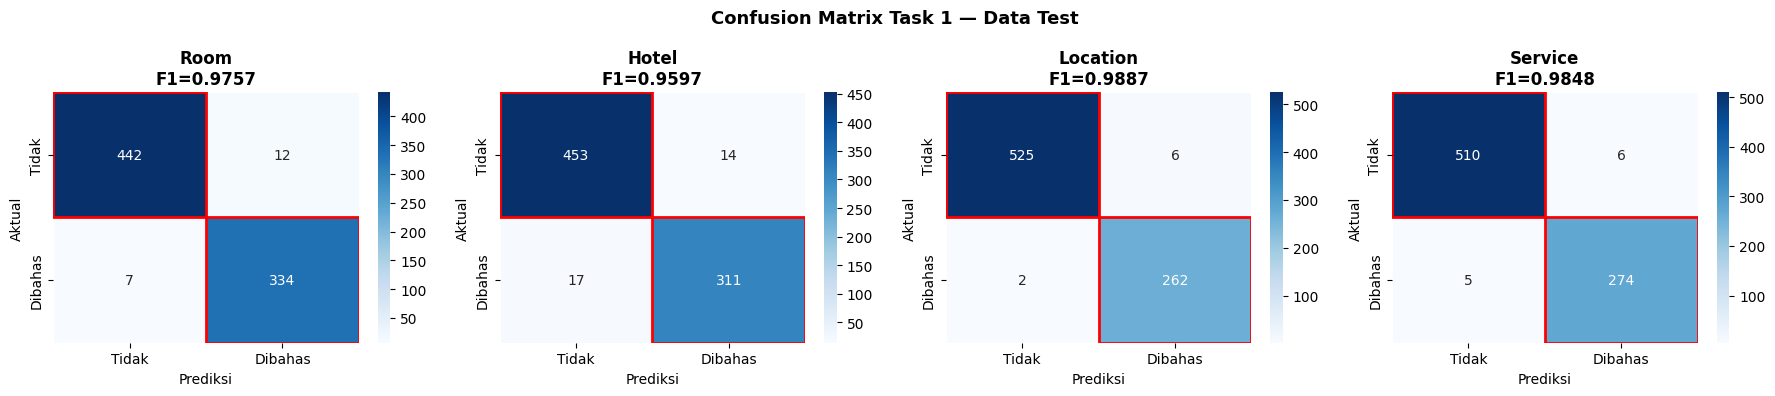


── ROC dan PR Curve per Aspek ──


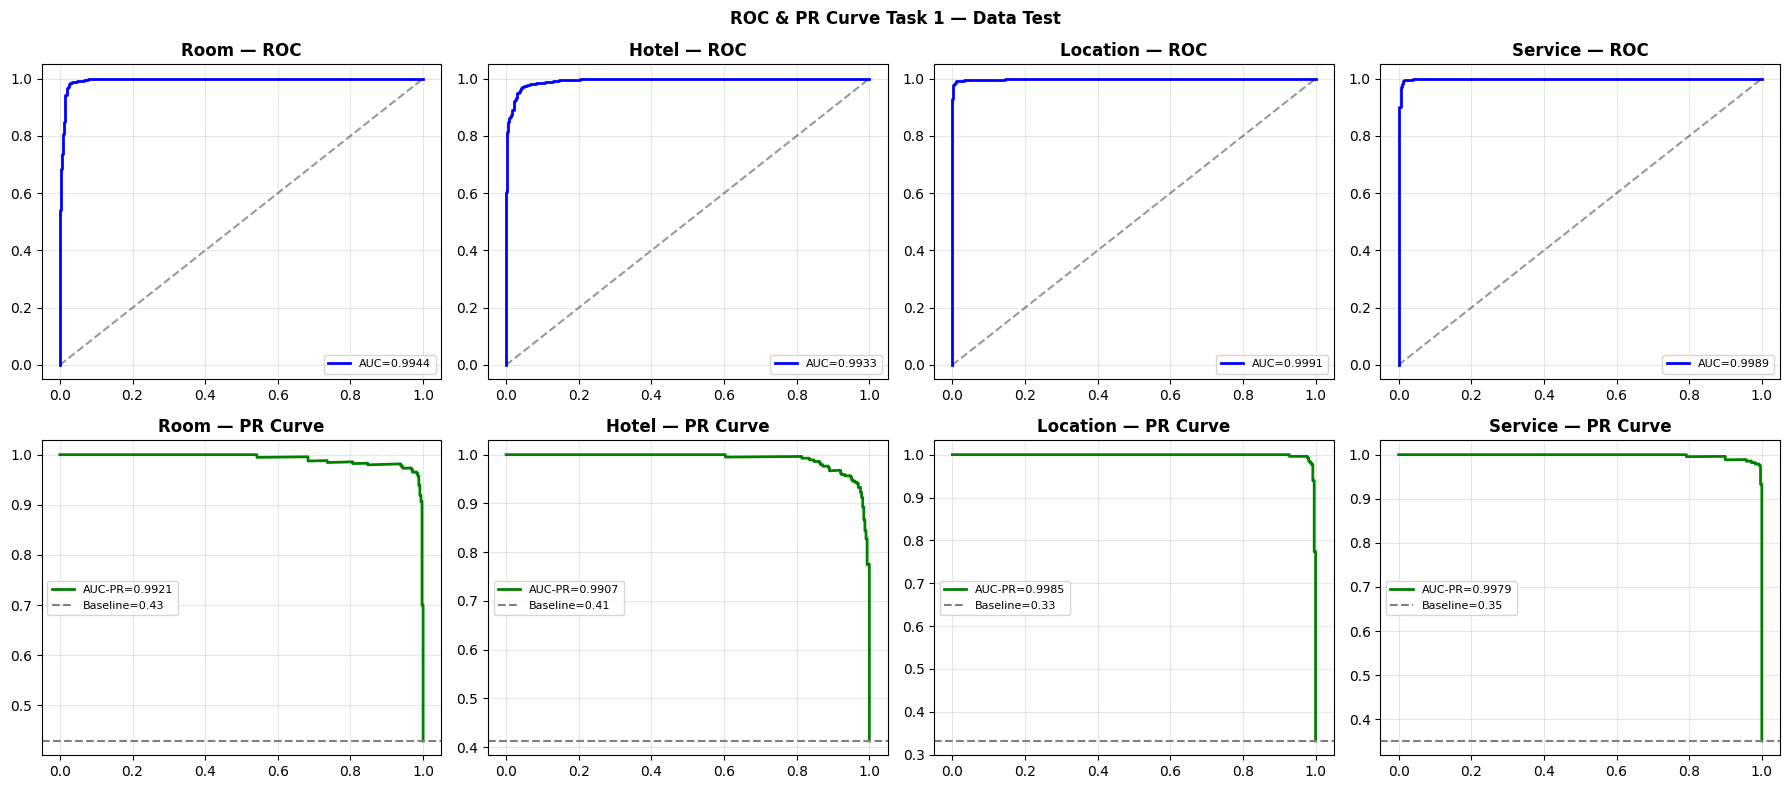


  AUC-ROC dan AUC-PR per Aspek:
  Room        : AUC-ROC=0.9944 AUC-PR=0.9921
  Hotel       : AUC-ROC=0.9933 AUC-PR=0.9907
  Location    : AUC-ROC=0.9991 AUC-PR=0.9985
  Service     : AUC-ROC=0.9989 AUC-PR=0.9979

── Perbandingan Train vs Test ──
  Hamming Accuracy K-Fold : 0.9762
  Hamming Accuracy Test   : 0.9783
  Subset Accuracy Test    : 0.9270
  Subset Accuracy K-Fold  : 0.9155


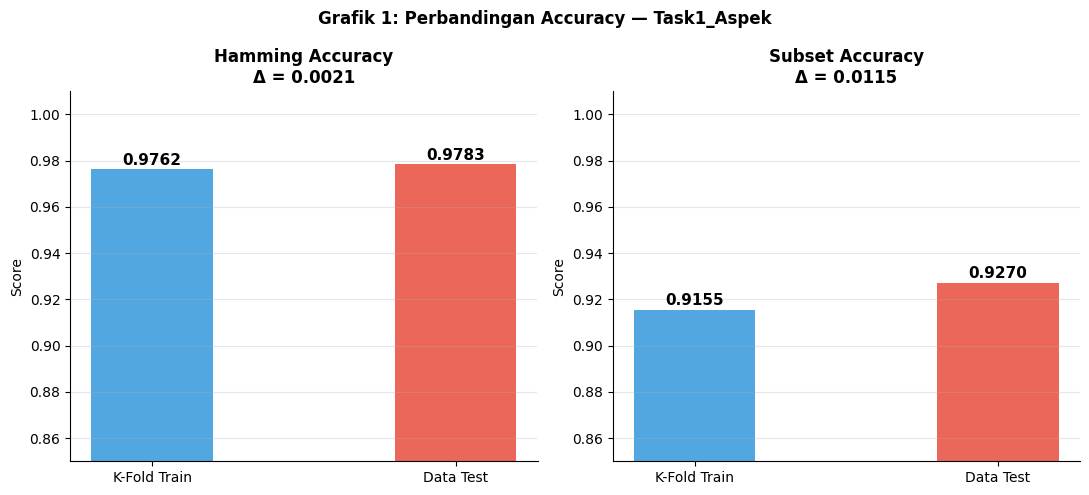

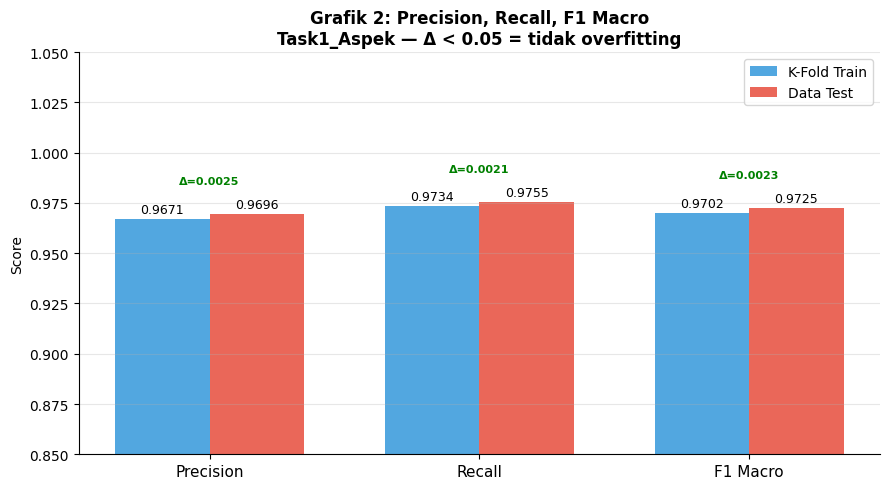


  Analisis overfitting:
  Precision     : KFold=0.9671 Test=0.9696 Δ=0.0025 → Tidak overfitting
  Recall        : KFold=0.9734 Test=0.9755 Δ=0.0021 → Tidak overfitting
  F1 Macro      : KFold=0.9702 Test=0.9725 Δ=0.0023 → Tidak overfitting
  Hamming Acc   : KFold=0.9762 Test=0.9783 Δ=0.0021

Prediksi disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final/Task1_Aspek/prediksi_test.csv

Task 1 evaluasi selesai!


In [ ]:
# ============================================================
# EVALUASI TASK 1 — KLASIFIKASI MULTILABEL
#
# Metrik khusus multilabel:
# - Hamming Loss: proporsi label yang salah prediksi
#   Nilai 0 = sempurna, mendekati 0 = sangat baik
# - Subset Accuracy: 1 jika SEMUA label benar
# - F1 Macro: rata-rata F1 per label (Room, Hotel, dll)
# - Micro avg: hitung TP/FP/FN dari semua label sekaligus
# - Weighted avg: rata-rata tertimbang jumlah sampel
# - Samples avg: rata-rata per sampel/ulasan
# ============================================================

task_name = 'Task1_Aspek'
cfg       = TASKS[task_name]
out_dir   = cfg['output_dir']
label_names = cfg['label_names']

print(f'{"="*60}')
print(f'  EVALUASI {task_name}')
print(f'{"="*60}')

# Load model dan tokenizer
print('\nLoad model...')
model     = load_model(cfg['model_path'],
                        custom_objects={'AUC': AUC})
with open(cfg['token_file'], 'rb') as f:
    tokenizer = pickle.load(f)

# Siapkan data test
print('Load data test...')
df_test = pd.read_csv(cfg['test_file'])
teks    = df_test[cfg['text_col']].fillna('').astype(str).tolist()
seq     = tokenizer.texts_to_sequences(teks)
X_test  = pad_sequences(seq, maxlen=MAX_LENGTH,
                         padding='post', truncating='post')
y_true  = df_test[cfg['label_cols']].values.astype(int)
print(f'Data test: {len(df_test):,} ulasan')

# Prediksi
print('Prediksi...')
y_prob = model.predict(X_test, batch_size=32, verbose=0)
y_pred = (y_prob >= 0.5).astype(int)

# ─────────────────────────────────
# A. Classification Report per aspek
# ─────────────────────────────────
print('\n── Classification Report per Aspek ──')
for i, label in enumerate(label_names):
    print(f'\n  [{label}]')
    print(classification_report(
        y_true[:, i], y_pred[:, i],
        target_names=['Tidak Dibahas', 'Dibahas']
    ))

# Classification Report multilabel lengkap
# (micro, macro, weighted, samples average)
print('\n── Classification Report Multilabel (semua aspek) ──')
print(classification_report(
    y_true, y_pred,
    target_names=label_names,
    zero_division=0
))

# ─────────────────────────────────
# B. Metrik multilabel keseluruhan
# ─────────────────────────────────
hl       = hamming_loss(y_true, y_pred)
sub_acc  = accuracy_score(y_true, y_pred)
f1_mac   = f1_score(y_true, y_pred, average='macro')
f1_mic   = f1_score(y_true, y_pred, average='micro')
prec_mac = precision_score(y_true, y_pred,
                            average='macro', zero_division=0)
rec_mac  = recall_score(y_true, y_pred, average='macro')

print('── Ringkasan Metrik ──')
# Hamming Loss: proporsi label yang salah
# Hamming Accuracy: proporsi label yang benar
#   = 1 - Hamming Loss (ini yang dicatat saat K-Fold)
# Subset Accuracy: 1 jika SEMUA label benar sekaligus
#   (lebih ketat, tidak dihitung saat K-Fold)
print(f'  Hamming Loss         : {hl:.4f}')
print(f'  Hamming Accuracy     : {1-hl:.4f}  '
      f'← dibandingkan dengan K-Fold ({KFOLD[task_name]["accuracy"]})')
print(f'  Subset Accuracy      : {sub_acc:.4f}  '
      f'(info tambahan, lebih ketat)')
print(f'  F1 Macro             : {f1_mac:.4f}')
print(f'  F1 Micro             : {f1_mic:.4f}')
print(f'  Precision Macro      : {prec_mac:.4f}')
print(f'  Recall Macro         : {rec_mac:.4f}')

# ─────────────────────────────────
# C. Confusion Matrix per aspek
# ─────────────────────────────────
print('\n── Confusion Matrix per Aspek ──')
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, (label, ax) in enumerate(
        zip(label_names, axes)):
    cm = confusion_matrix(y_true[:,i], y_pred[:,i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Tidak','Dibahas'],
                yticklabels=['Tidak','Dibahas'],
                ax=ax, linewidths=0.5)
    for j in range(2):
        ax.add_patch(plt.Rectangle(
            (j,j),1,1,fill=False,
            edgecolor='red',lw=2))
    f1i = f1_score(y_true[:,i], y_pred[:,i],
                   average='macro')
    ax.set_title(f'{label}\nF1={f1i:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.suptitle('Confusion Matrix Task 1 — Data Test',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(out_dir+'cm_all_aspek_test.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────
# D. ROC dan PR Curve per aspek
# ─────────────────────────────────
print('\n── ROC dan PR Curve per Aspek ──')
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
aucpr_per_aspek = []
for i, label in enumerate(label_names):
    yt  = y_true[:, i]
    ypr = y_prob[:, i]

    # ROC
    fpr, tpr, _ = roc_curve(yt, ypr)
    auc_r = roc_auc_score(yt, ypr)
    axes[0,i].plot(fpr, tpr, 'b-', lw=2,
                   label=f'AUC={auc_r:.4f}')
    axes[0,i].plot([0,1],[0,1],'k--',alpha=0.4)
    axes[0,i].set_title(f'{label} — ROC',
                         fontweight='bold')
    axes[0,i].legend(fontsize=8)
    axes[0,i].grid(alpha=0.3)

    # PR — fokus kelas Dibahas (=1 = minoritas)
    prec, rec, _ = precision_recall_curve(yt, ypr)
    auc_p = average_precision_score(yt, ypr)
    base  = yt.mean()
    axes[1,i].plot(rec, prec, 'g-', lw=2,
                   label=f'AUC-PR={auc_p:.4f}')
    axes[1,i].axhline(base, color='gray',
                       linestyle='--',
                       label=f'Baseline={base:.2f}')
    axes[1,i].set_title(f'{label} — PR Curve',
                         fontweight='bold')
    axes[1,i].legend(fontsize=8)
    axes[1,i].grid(alpha=0.3)
    aucpr_per_aspek.append({'aspek':label,
                             'auc_roc':round(auc_r,4),
                             'auc_pr':round(auc_p,4)})

plt.suptitle('ROC & PR Curve Task 1 — Data Test',
             fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir+'roc_pr_all_aspek_test.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\n  AUC-ROC dan AUC-PR per Aspek:')
for r in aucpr_per_aspek:
    print(f'  {r["aspek"]:<12}: '
          f'AUC-ROC={r["auc_roc"]} '
          f'AUC-PR={r["auc_pr"]}')

# ─────────────────────────────────
# E. Perbandingan Train vs Test — 2 Grafik
# Grafik 1: Hamming Accuracy + Subset Accuracy
# Grafik 2: Precision, Recall, F1 Macro
print('\n── Perbandingan Train vs Test ──')

hamming_acc = 1 - hl  # Hamming Accuracy = 1 - Hamming Loss

# Isi nilai ini dari hasil notebook hitung_subset_acc_kfold!
# Contoh: subset_acc_kfold = 0.9170
subset_acc_kfold = KFOLD[task_name].get('subset_acc', None)

print(f'  Hamming Accuracy K-Fold : '
      f'{KFOLD[task_name]["accuracy"]:.4f}')
print(f'  Hamming Accuracy Test   : {hamming_acc:.4f}')
print(f'  Subset Accuracy Test    : {sub_acc:.4f}')
if subset_acc_kfold:
    print(f'  Subset Accuracy K-Fold  : {subset_acc_kfold:.4f}')

# ── Grafik 1: Perbandingan Accuracy ──
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Panel kiri: Hamming Accuracy
kfold_ha = KFOLD[task_name]['accuracy']
d_ha     = abs(kfold_ha - hamming_acc)
b1 = axes[0].bar(['K-Fold Train','Data Test'],
                  [kfold_ha, hamming_acc],
                  color=['#3498db','#e74c3c'],
                  alpha=0.85, width=0.4)
for bar in b1:
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.002,
                 f'{bar.get_height():.4f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title(
    f'Hamming Accuracy\nΔ = {d_ha:.4f}',
    fontweight='bold')
axes[0].set_ylim(0.85, 1.01)
axes[0].set_ylabel('Score')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Panel kanan: Subset Accuracy
if subset_acc_kfold:
    d_sa = abs(subset_acc_kfold - sub_acc)
    b2 = axes[1].bar(['K-Fold Train','Data Test'],
                      [subset_acc_kfold, sub_acc],
                      color=['#3498db','#e74c3c'],
                      alpha=0.85, width=0.4)
    for bar in b2:
        axes[1].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+0.002,
                     f'{bar.get_height():.4f}',
                     ha='center', fontsize=11, fontweight='bold')
    axes[1].set_title(
        f'Subset Accuracy\nΔ = {d_sa:.4f}',
        fontweight='bold')
    axes[1].set_ylim(0.85, 1.01)
    axes[1].set_ylabel('Score')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)
else:
    axes[1].text(0.5, 0.5,
        'Isi subset_acc_kfold dulu\ndari notebook\nhitung_subset_acc_kfold',
        ha='center', va='center',
        transform=axes[1].transAxes,
        fontsize=10, color='gray')
    axes[1].set_title('Subset Accuracy', fontweight='bold')

plt.suptitle(
    f'Grafik 1: Perbandingan Accuracy — {task_name}',
    fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(out_dir+'train_vs_test_accuracy.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Grafik 2: Precision, Recall, F1 ──
metrik2  = ['Precision','Recall','F1 Macro']
kfold_v2 = [KFOLD[task_name]['precision'],
             KFOLD[task_name]['recall'],
             KFOLD[task_name]['f1']]
test_v2  = [prec_mac, rec_mac, f1_mac]

x, w = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b3 = ax.bar(x-w/2, kfold_v2, w,
             label='K-Fold Train',
             color='#3498db', alpha=0.85)
b4 = ax.bar(x+w/2, test_v2, w,
             label='Data Test',
             color='#e74c3c', alpha=0.85)

for bar in list(b3)+list(b4):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.003,
            f'{bar.get_height():.4f}',
            ha='center', fontsize=9)
for i, (k, t) in enumerate(zip(kfold_v2, test_v2)):
    d = abs(k-t)
    c = 'green' if d < 0.05 else 'red'
    ax.text(i, max(k,t)+0.015, f'Δ={d:.4f}',
            ha='center', fontsize=8,
            color=c, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrik2, fontsize=11)
ax.set_ylim(0.85, 1.05)
ax.set_ylabel('Score')
ax.set_title(
    f'Grafik 2: Precision, Recall, F1 Macro\n'
    f'{task_name} — Δ < 0.05 = tidak overfitting',
    fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(out_dir+'train_vs_test_prf.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Analisis overfitting
print('\n  Analisis overfitting:')
for m, k, t in zip(metrik2, kfold_v2, test_v2):
    d = abs(k-t)
    s = 'Tidak overfitting' if d < 0.05 else 'Perlu dicek'
    print(f'  {m:<14}: KFold={k:.4f} '
          f'Test={t:.4f} Δ={d:.4f} → {s}')
print(f'  Hamming Acc   : '
      f'KFold={kfold_ha:.4f} '
      f'Test={hamming_acc:.4f} Δ={d_ha:.4f}')


# ─────────────────────────────────
# F. Simpan prediksi ke CSV
# ─────────────────────────────────
df_out = df_test.copy()
for i, label in enumerate(label_names):
    df_out[f'pred_{label}'] = y_pred[:, i]
    df_out[f'prob_{label}'] = y_prob[:, i].round(4)
df_out.to_csv(out_dir+'prediksi_test.csv', index=False)
print(f'\nPrediksi disimpan: {out_dir}prediksi_test.csv')

# Simpan rekap metrik untuk Excel
rekap_t1_multilabel = {
    'hamming_loss':round(hl,4),
    'subset_accuracy':round(sub_acc,4),
    'f1_macro':round(f1_mac,4),
    'f1_micro':round(f1_mic,4),
    'precision_macro':round(prec_mac,4),
    'recall_macro':round(rec_mac,4),
}
print(f'\nTask 1 evaluasi selesai!')


## 4. Evaluasi Task 2–5 (Binary Classification)



  EVALUASI Task2_Room
  Kelas Minoritas: Positif


Data test: 341 ulasan

── Classification Report ──
              precision    recall  f1-score   support

     Negatif       0.98      1.00      0.99       181
     Positif       1.00      0.97      0.99       160

    accuracy                           0.99       341
   macro avg       0.99      0.99      0.99       341
weighted avg       0.99      0.99      0.99       341

  Accuracy  : 0.9883
  F1 Macro  : 0.9882
  Precision : 0.9892
  Recall    : 0.9875
  AUC-ROC   : 0.9974
  AUC-PR (Positif): 0.9975

── Confusion Matrix ──


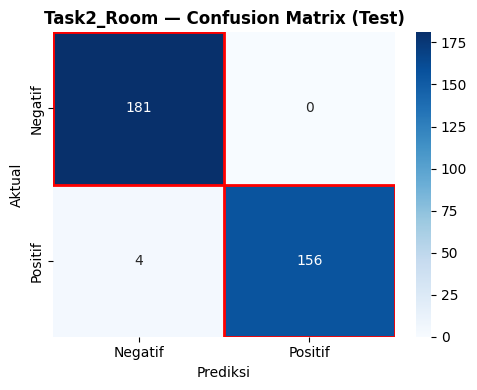


── ROC dan PR Curve ──


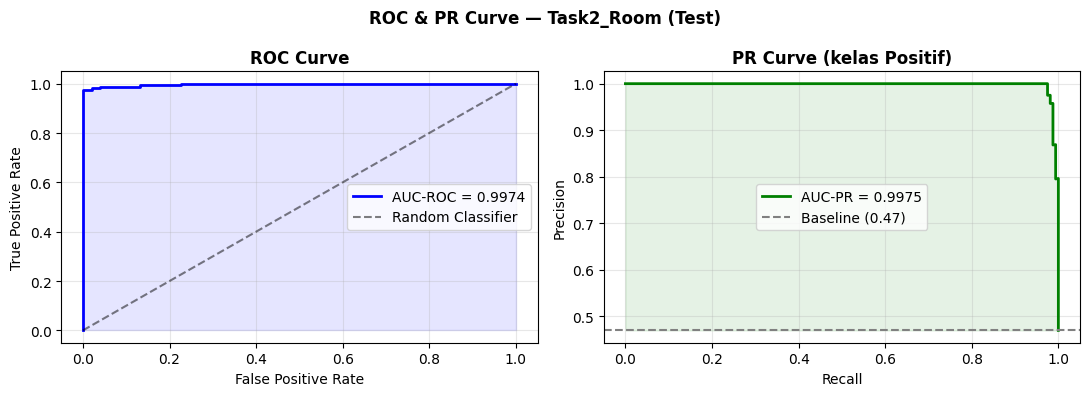


── Perbandingan Train vs Test ──


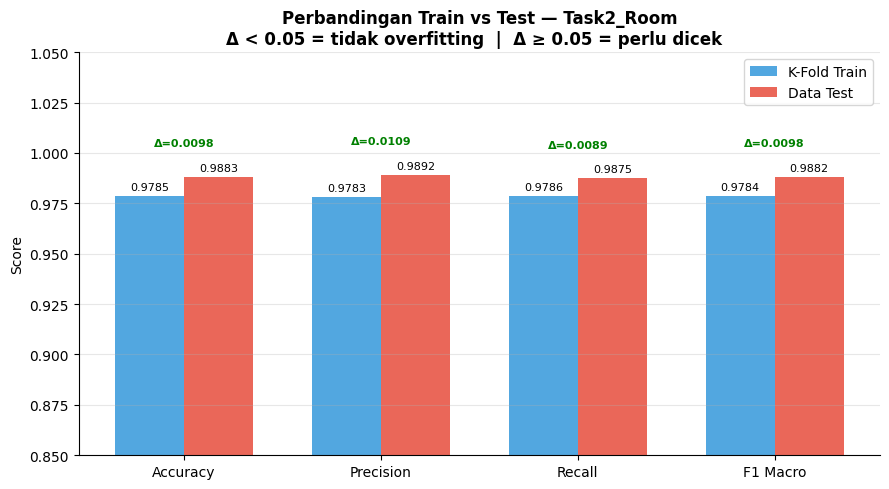


  Analisis overfitting:
  Accuracy    : KFold=0.9785 Test=0.9883 Δ=0.0098 → Tidak overfitting
  Precision   : KFold=0.9783 Test=0.9892 Δ=0.0109 → Tidak overfitting
  Recall      : KFold=0.9786 Test=0.9875 Δ=0.0089 → Tidak overfitting
  F1 Macro    : KFold=0.9784 Test=0.9882 Δ=0.0098 → Tidak overfitting

Prediksi disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final/Task2_Room/prediksi_test.csv
Task2_Room evaluasi selesai!

  EVALUASI Task3_Hotel
  Kelas Minoritas: Negatif


Data test: 328 ulasan

── Classification Report ──
              precision    recall  f1-score   support

     Negatif       0.96      0.92      0.94       128
     Positif       0.95      0.97      0.96       200

    accuracy                           0.95       328
   macro avg       0.96      0.95      0.95       328
weighted avg       0.95      0.95      0.95       328

  Accuracy  : 0.9543
  F1 Macro  : 0.9516
  Precision : 0.9553
  Recall    : 0.9484
  AUC-ROC   : 0.9838
  AUC-PR (Negatif): 0.9738

── Confusion Matrix ──


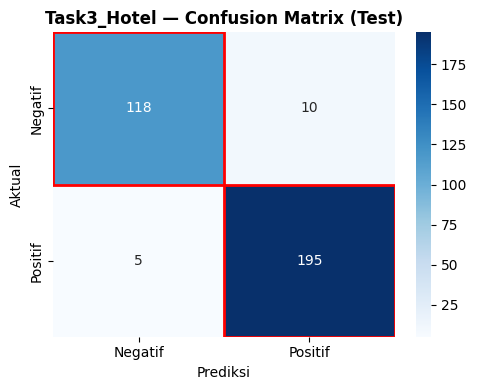


── ROC dan PR Curve ──


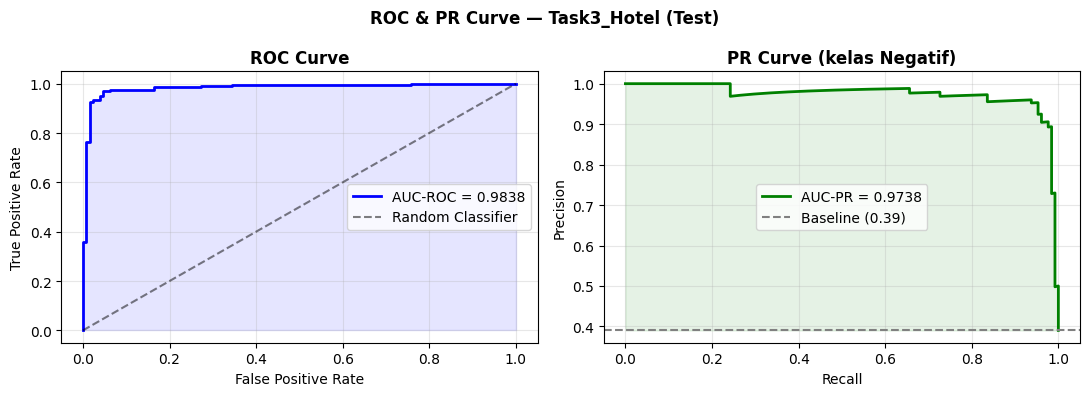


── Perbandingan Train vs Test ──


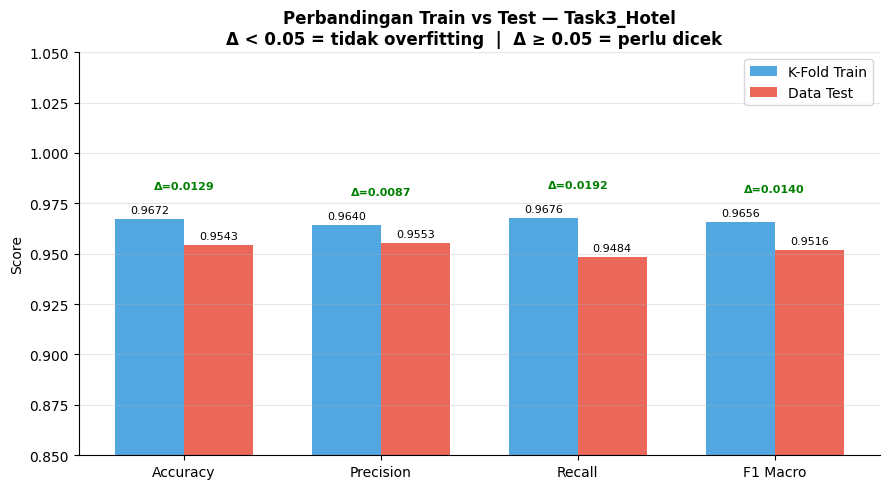


  Analisis overfitting:
  Accuracy    : KFold=0.9672 Test=0.9543 Δ=0.0129 → Tidak overfitting
  Precision   : KFold=0.9640 Test=0.9553 Δ=0.0087 → Tidak overfitting
  Recall      : KFold=0.9676 Test=0.9484 Δ=0.0192 → Tidak overfitting
  F1 Macro    : KFold=0.9656 Test=0.9516 Δ=0.0140 → Tidak overfitting

Prediksi disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final/Task3_Hotel/prediksi_test.csv
Task3_Hotel evaluasi selesai!

  EVALUASI Task4_Location
  Kelas Minoritas: Negatif


Data test: 264 ulasan

── Classification Report ──
              precision    recall  f1-score   support

     Negatif       0.95      0.95      0.95        60
     Positif       0.99      0.99      0.99       204

    accuracy                           0.98       264
   macro avg       0.97      0.97      0.97       264
weighted avg       0.98      0.98      0.98       264

  Accuracy  : 0.9773
  F1 Macro  : 0.9676
  Precision : 0.9676
  Recall    : 0.9676
  AUC-ROC   : 0.9925
  AUC-PR (Negatif): 0.9572

── Confusion Matrix ──


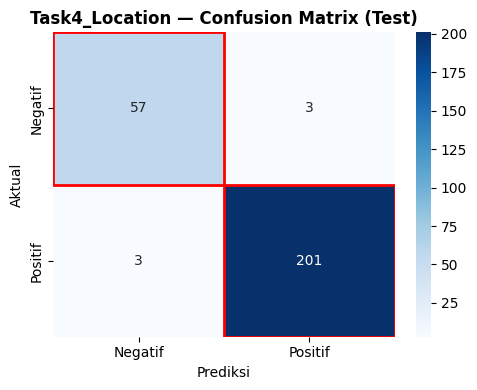


── ROC dan PR Curve ──


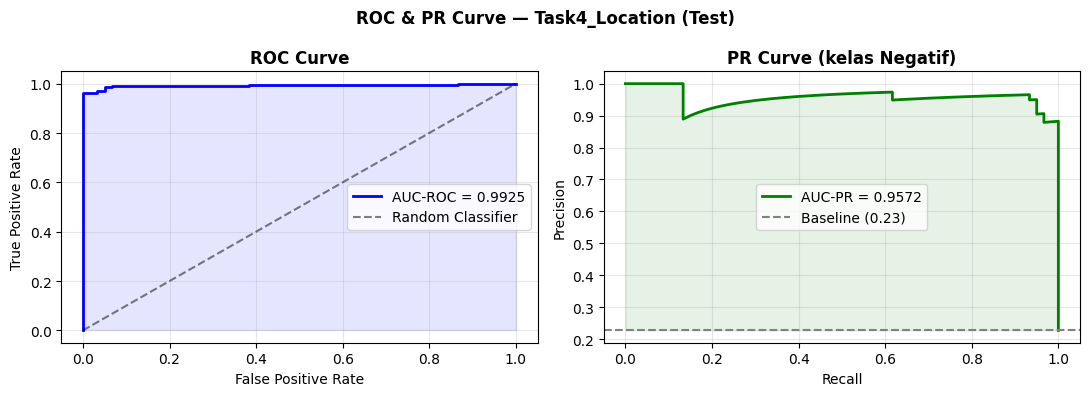


── Perbandingan Train vs Test ──


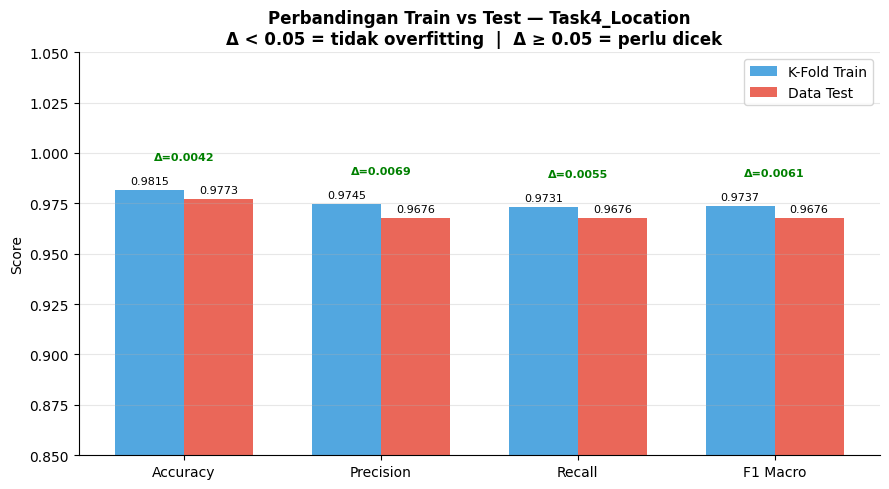


  Analisis overfitting:
  Accuracy    : KFold=0.9815 Test=0.9773 Δ=0.0042 → Tidak overfitting
  Precision   : KFold=0.9745 Test=0.9676 Δ=0.0069 → Tidak overfitting
  Recall      : KFold=0.9731 Test=0.9676 Δ=0.0055 → Tidak overfitting
  F1 Macro    : KFold=0.9737 Test=0.9676 Δ=0.0061 → Tidak overfitting

Prediksi disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final/Task4_Location/prediksi_test.csv
Task4_Location evaluasi selesai!

  EVALUASI Task5_Service
  Kelas Minoritas: Negatif


Data test: 279 ulasan

── Classification Report ──
              precision    recall  f1-score   support

     Negatif       0.98      0.95      0.96       100
     Positif       0.97      0.99      0.98       179

    accuracy                           0.97       279
   macro avg       0.98      0.97      0.97       279
weighted avg       0.97      0.97      0.97       279

  Accuracy  : 0.9749
  F1 Macro  : 0.9725
  Precision : 0.9760
  Recall    : 0.9694
  AUC-ROC   : 0.9988
  AUC-PR (Negatif): 0.9978

── Confusion Matrix ──


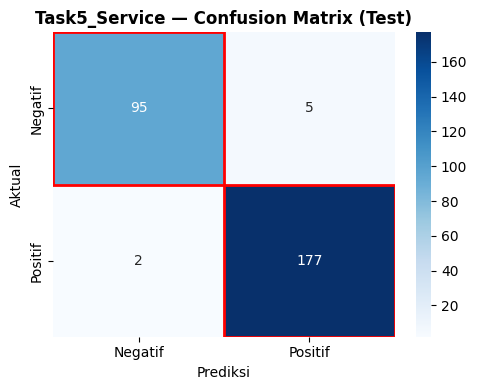


── ROC dan PR Curve ──


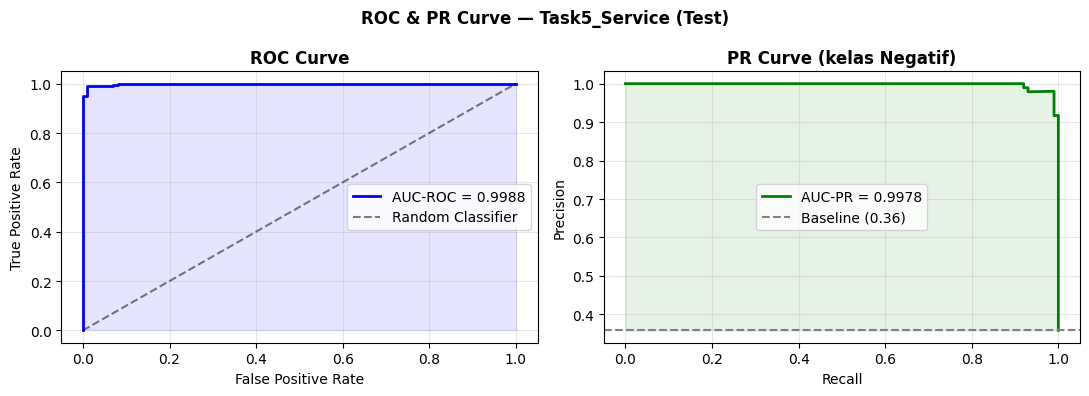


── Perbandingan Train vs Test ──


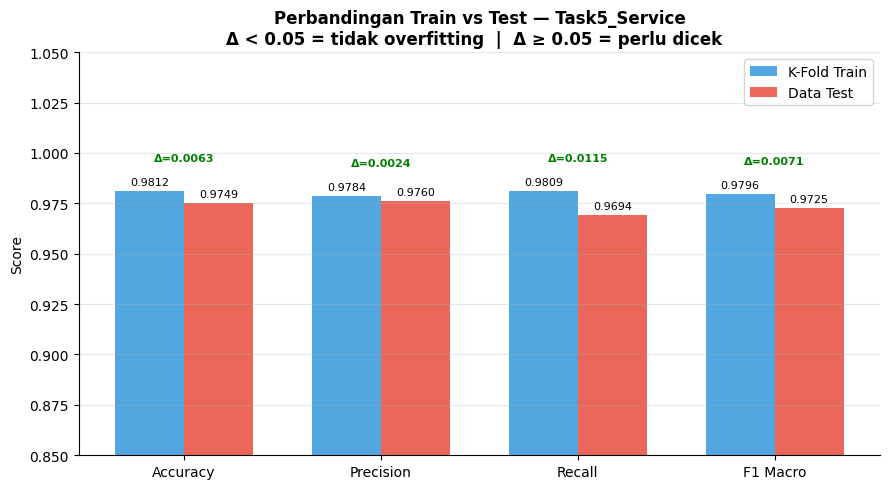


  Analisis overfitting:
  Accuracy    : KFold=0.9812 Test=0.9749 Δ=0.0063 → Tidak overfitting
  Precision   : KFold=0.9784 Test=0.9760 Δ=0.0024 → Tidak overfitting
  Recall      : KFold=0.9809 Test=0.9694 Δ=0.0115 → Tidak overfitting
  F1 Macro    : KFold=0.9796 Test=0.9725 Δ=0.0071 → Tidak overfitting

Prediksi disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final/Task5_Service/prediksi_test.csv
Task5_Service evaluasi selesai!


In [ ]:
# ============================================================
# EVALUASI TASK 2-5 — KLASIFIKASI BINER
#
# Metrik binary:
# - Classification Report: precision, recall, F1 per kelas
# - F1 Macro: rata-rata F1 Negatif dan Positif
# - AUC-ROC: kemampuan membedakan kelas (0.5=random, 1=sempurna)
# - AUC-PR: lebih informatif untuk data tidak seimbang
#   (baseline = proporsi kelas minoritas)
# ============================================================

rekap_test = []  # menyimpan hasil semua task

for task_name in ['Task2_Room','Task3_Hotel',
                   'Task4_Location','Task5_Service']:
    cfg       = TASKS[task_name]
    out_dir   = cfg['output_dir']
    min_idx   = cfg['min_idx']
    minoritas = cfg['minoritas']

    print(f'\n{"="*60}')
    print(f'  EVALUASI {task_name}')
    print(f'  Kelas Minoritas: {minoritas}')
    print(f'{"="*60}')

    # Load model dan tokenizer
    tf.keras.backend.clear_session()
    model = load_model(cfg['model_path'],
                        custom_objects={'AUC': AUC})
    with open(cfg['token_file'], 'rb') as f:
        tokenizer = pickle.load(f)

    # Siapkan data test
    df_test = pd.read_csv(cfg['test_file'])
    teks    = df_test[cfg['text_col']].fillna('').astype(str).tolist()
    seq     = tokenizer.texts_to_sequences(teks)
    X_test  = pad_sequences(seq, maxlen=MAX_LENGTH,
                             padding='post', truncating='post')
    y_true  = df_test[cfg['label_cols'][0]].values.astype(int)
    print(f'Data test: {len(df_test):,} ulasan')

    # Prediksi
    y_prob = model.predict(
        X_test, batch_size=32, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    # ── A. Classification Report ──
    print('\n── Classification Report ──')
    print(classification_report(
        y_true, y_pred,
        target_names=['Negatif','Positif']
    ))

    # ── B. Metrik ──
    acc     = accuracy_score(y_true, y_pred)
    f1_mac  = f1_score(y_true, y_pred, average='macro')
    prec    = precision_score(y_true, y_pred,
                              average='macro', zero_division=0)
    rec     = recall_score(y_true, y_pred, average='macro')
    auc_roc = roc_auc_score(y_true, y_prob)
    if min_idx == 0:
        auc_pr = average_precision_score(
            1-y_true, 1-y_prob)
    else:
        auc_pr = average_precision_score(y_true, y_prob)

    print(f'  Accuracy  : {acc:.4f}')
    print(f'  F1 Macro  : {f1_mac:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  AUC-ROC   : {auc_roc:.4f}')
    print(f'  AUC-PR ({minoritas}): {auc_pr:.4f}')

    # ── C. Confusion Matrix ──
    print('\n── Confusion Matrix ──')
    tampilkan_confusion_matrix(
        y_true, y_pred, ['Negatif','Positif'],
        f'{task_name} — Confusion Matrix (Test)',
        out_dir+'cm_test.png'
    )

    # ── D. ROC dan PR Curve ──
    print('\n── ROC dan PR Curve ──')
    tampilkan_roc_pr(
        y_true, y_prob, minoritas, min_idx,
        f'ROC & PR Curve — {task_name} (Test)',
        out_dir+'roc_pr_test.png'
    )

    # ── E. Perbandingan Train vs Test ──
    print('\n── Perbandingan Train vs Test ──')
    plot_train_vs_test(
        KFOLD[task_name],
        {'f1':f1_mac,'precision':prec,
         'recall':rec,'accuracy':acc},
        task_name,
        out_dir+'train_vs_test.png'
    )

    # ── F. Simpan prediksi ke CSV ──
    # CSV berisi: teks ulasan, label asli, prediksi,
    # probabilitas, dan flag benar/salah.
    # Berguna jika dosen meminta metrik tambahan.
    df_out = df_test.copy()
    df_out['y_true']   = y_true
    df_out['y_pred']   = y_pred
    df_out['prob_pos'] = y_prob.round(4)
    df_out['benar']    = (y_true == y_pred).astype(int)
    df_out.to_csv(out_dir+'prediksi_test.csv', index=False)

    rekap_test.append({
        'task'        : task_name,
        'n_test'      : len(df_test),
        'accuracy'    : round(acc,4),
        'precision'   : round(prec,4),
        'recall'      : round(rec,4),
        'f1_macro'    : round(f1_mac,4),
        'auc_roc'     : round(auc_roc,4),
        'auc_pr'      : round(auc_pr,4),
        'kfold_f1'    : KFOLD[task_name]['f1'],
        'selisih_f1'  : round(abs(
            f1_mac-KFOLD[task_name]['f1']),4),
    })

    print(f'\nPrediksi disimpan: {out_dir}prediksi_test.csv')
    print(f'{task_name} evaluasi selesai!')


## 5. Rekap Final dan Simpan ke Excel


In [ ]:
# Tampilkan ringkasan hasil evaluasi semua task
# dan simpan ke Excel.

df_rekap = pd.DataFrame(rekap_test)

print('='*70)
print('  REKAP EVALUASI DATA TEST')
print('='*70)
print(f'  {"Task":<18} {"Acc":>7} {"Prec":>7} '
      f'{"Rec":>7} {"F1":>7} '
      f'{"AUC-ROC":>9} {"Δ F1":>8}')
print(f'  {"-"*65}')
for _, r in df_rekap.iterrows():
    s = 'Tidak overfitting' if r['selisih_f1']<0.05 \
        else 'Perlu dicek'
    print(f'  {r["task"]:<18} '
          f'{r["accuracy"]:>7.4f} '
          f'{r["precision"]:>7.4f} '
          f'{r["recall"]:>7.4f} '
          f'{r["f1_macro"]:>7.4f} '
          f'{r["auc_roc"]:>9.4f} '
          f'{r["selisih_f1"]:>7.4f} ({s})')

print('\n  Keterangan: Δ F1 = |F1 K-Fold − F1 Test|')

# Simpan ke Excel dengan 3 sheet
excel_path = FINAL_DIR + 'rekap_evaluasi_test.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as w:
    # Sheet 1: Task 2-5 binary
    df_rekap.to_excel(w, sheet_name='Task2_5',
                       index=False)
    # Sheet 2: Task 1 multilabel
    pd.DataFrame([rekap_t1_multilabel]).to_excel(
        w, sheet_name='Task1_Multilabel', index=False)
    # Sheet 3: Task 1 AUC per aspek
    pd.DataFrame(aucpr_per_aspek).to_excel(
        w, sheet_name='Task1_AUC_per_aspek', index=False)

print(f'\nRekap disimpan: {excel_path}')
print('\nFile CSV prediksi per task:')
for tn, cfg in TASKS.items():
    p = cfg['output_dir']+'prediksi_test.csv'
    if os.path.exists(p):
        n = len(pd.read_csv(p))
        print(f'  {tn}: {n:,} baris → {p}')

  REKAP EVALUASI DATA TEST
  Task                   Acc    Prec     Rec      F1   AUC-ROC     Δ F1
  -----------------------------------------------------------------
  Task2_Room          0.9883  0.9892  0.9875  0.9882    0.9974  0.0098 (Tidak overfitting)
  Task3_Hotel         0.9543  0.9553  0.9484  0.9516    0.9838  0.0140 (Tidak overfitting)
  Task4_Location      0.9773  0.9676  0.9676  0.9676    0.9925  0.0061 (Tidak overfitting)
  Task5_Service       0.9749  0.9760  0.9694  0.9725    0.9988  0.0071 (Tidak overfitting)

  Keterangan: Δ F1 = |F1 K-Fold − F1 Test|

Rekap disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final/rekap_evaluasi_test.xlsx

File CSV prediksi per task:
  Task1_Aspek: 795 baris → /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final/Task1_Aspek/prediksi_test.csv
  Task2_Room: 341 baris → /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final/Task2_Room/prediksi_test.csv
  Task3_Hotel: 328 baris → /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Mod